In [1]:
import geopandas
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon, shape, Point
import math
import re

In [2]:
#gdf = geopandas.read_file('/Users/tili/Desktop/CIIR/results/Tissue_annotation_qupath_geojson_output/200116_ST-AR_BC_A_B_V19T26-012_KT_V1-Spot000001.geojson')

In [7]:
#gdf.geometry[1]

In [2]:
# Load metadata
info = pd.read_csv('/Users/tili/Desktop/CIIR/data/ST-AR_Visium_samples.csv')

# Get sample ID
info['sampleID'] = info['Patientid'] + info['Tumor area']
info

,Patient,Patientid,Tumor area,Visium ID,Visum h5ad ID,name,type,width,height,sampleID
0,TD-2532-BCSA1,BCSA1,TumA1,V19T26-012_A1,200116_ST-AR_BC_A_B_V19T26-012_KT_V1-Spot00000...,a1.012,TNBC,29184,29696,BCSA1TumA1
1,TD-2532-BCSA1,BCSA1,TumA2,V19T26-012_B1,200116_ST-AR_BC_A_B_V19T26-012_KT_V2-Spot00000...,b1.012,TNBC,29184,29696,BCSA1TumA2
2,TD-2532-BCSA1,BCSA1,TumB1,V19T26-012_C1,200116_ST-AR_BC_A_B_V19T26-012_KT_V3-Spot00000...,c1.012,TNBC,29184,29696,BCSA1TumB1
3,TD-2532-BCSA1,BCSA1,TumB2,V19T26-012_D1,200116_ST-AR_BC_A_B_V19T26-012_KT_V4-Spot00000...,d1.012,TNBC,29184,29696,BCSA1TumB2
4,TD-2532-BCSA2,BCSA2,TumB1,V10F24-112_C1,200616_BC-SA2_V10F24-112_KT.C1-Spot000001.h5ad,c1.112,HER2+,47616,48128,BCSA2TumB1
5,TD-2532-BCSA2,BCSA2,TumB2,V10F24-112_D1,200616_BC-SA2_V10F24-112_KT.D1-Spot000001.h5ad,d1.112,HER2+,47616,48128,BCSA2TumB2
6,TD-2532-BCSA2,BCSA2,TumC1,V10F24-113_A1,200715_BC_SA2_C_D_V10F24-113.A1-Spot000001.h5ad,a1.113,HER2+,48640,47104,BCSA2TumC1
7,TD-2532-BCSA2,BCSA2,TumC2,V10F24-113_B1,200715_BC_SA2_C_D_V10F24-113.B1-Spot000001.h5ad,b1.113,HER2+,48640,47104,BCSA2TumC2
8,TD-2532-BCSA2,BCSA2,TumD1,V10F24-113_C1,200715_BC_SA2_C_D_V10F24-113.C1-Spot000001.h5ad,c1.113,HER2+,48640,47104,BCSA2TumD1
9,TD-2532-BCSA2,BCSA2,TumD2,V10F24-113_D1,200715_BC_SA2_C_D_V10F24-113.D1-Spot000001.h5ad,d1.113,HER2+,48640,47104,BCSA2TumD2


In [3]:
def create_regular_polygon(center, radius, num_vertices):
    """
    Create a regular polygon with a specified number of vertices centered at a given point.
    :param center: A shapely.geometry.point. Point representing the center of the polygon.
    :param radius: The radius of the polygon (distance from the center to any vertex).
    :param num_vertices: The number of vertices (and sides) of the polygon.
    :return: A shapely.geometry.polygon.Polygon representing the regular polygon.
    """
    angle_between_vertices = 2 * math.pi / num_vertices
    vertices = [
        (
            center.x + radius * math.cos(i * angle_between_vertices),
            center.y + radius * math.sin(i * angle_between_vertices)
        )
        for i in range(num_vertices)
    ]
    return Polygon(vertices)

Tumor
Tumor
Tumor
Tumor
Tumor
Tumor
Tumor
Tumor
Tumor
Tumor
Tumor


/Users/tili/miniconda3/lib/python3.12/site-packages/geopandas/plotting.py:684: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


Tumor


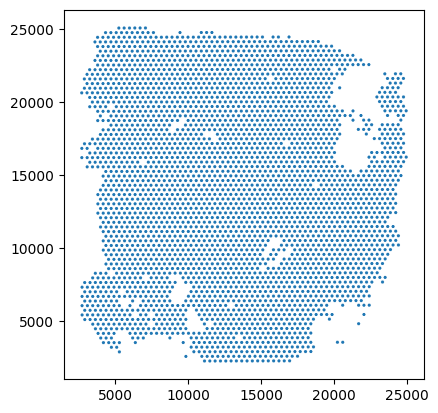

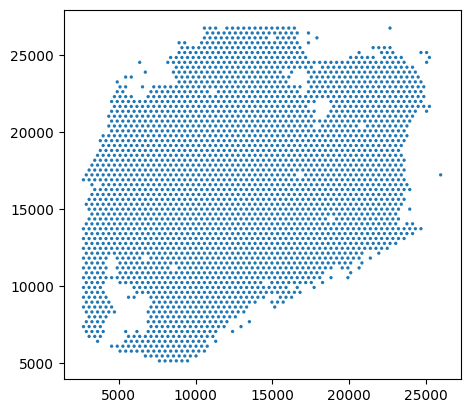

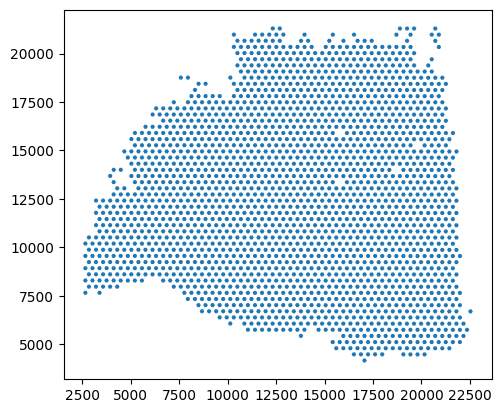

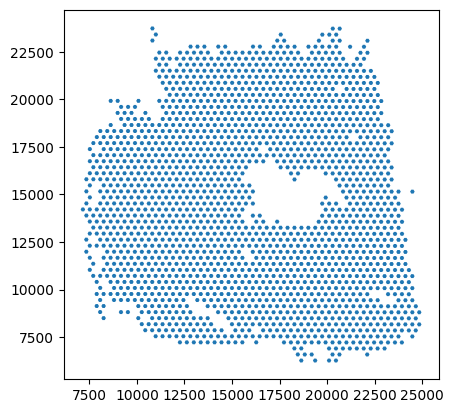

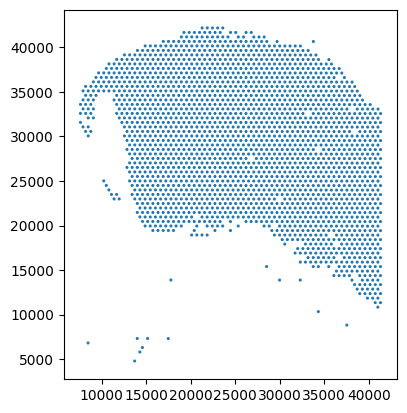

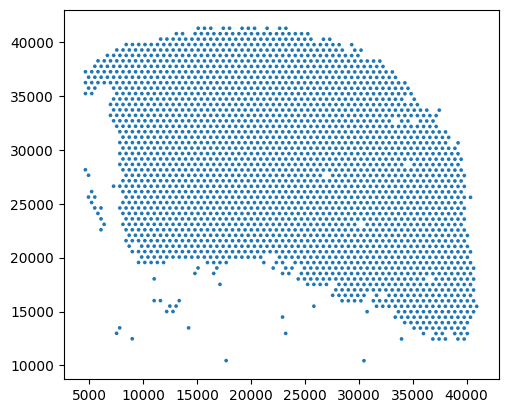

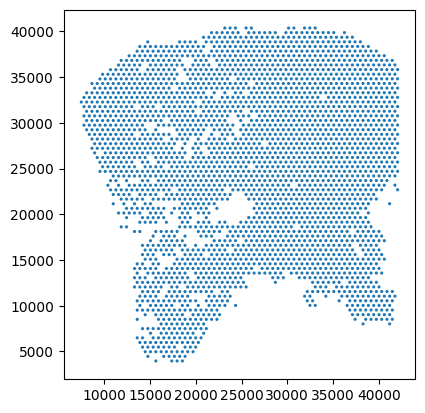

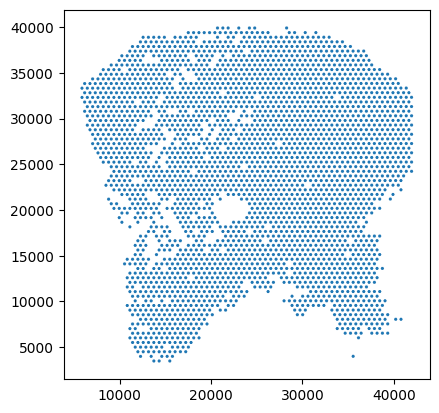

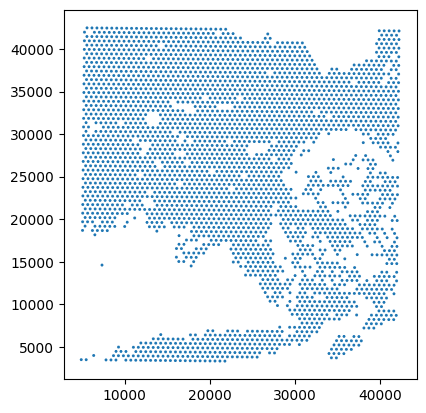

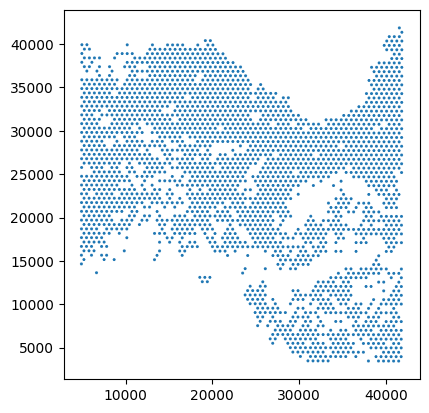

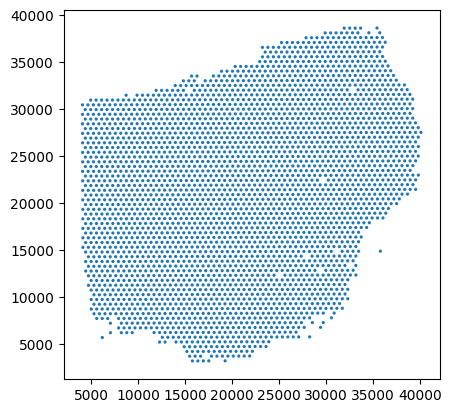

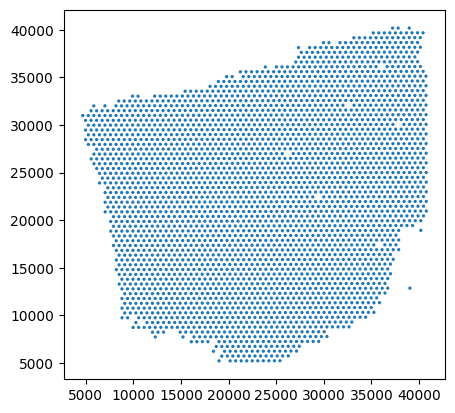

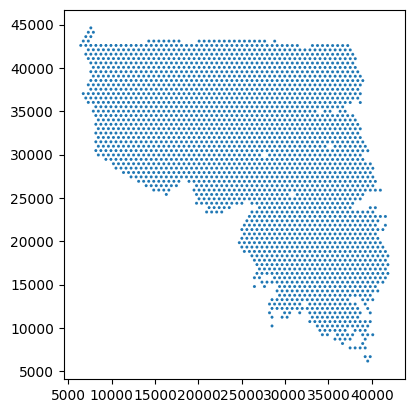

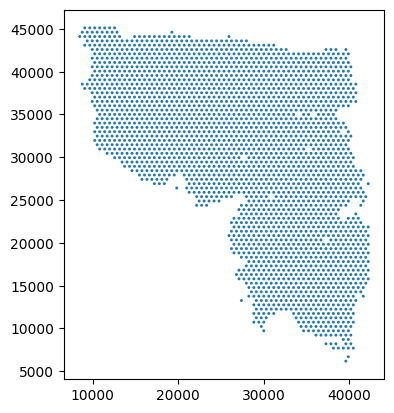

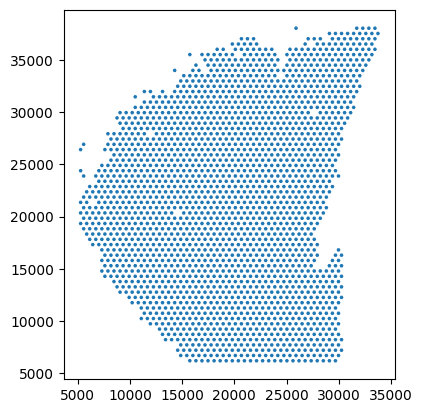

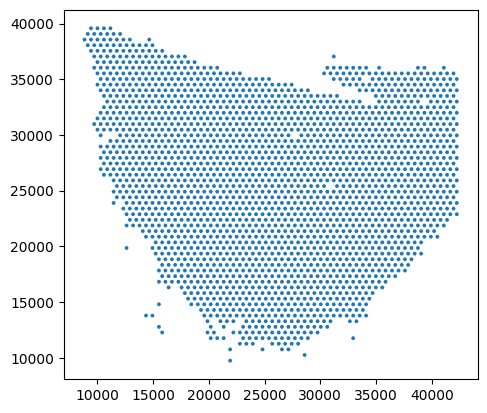

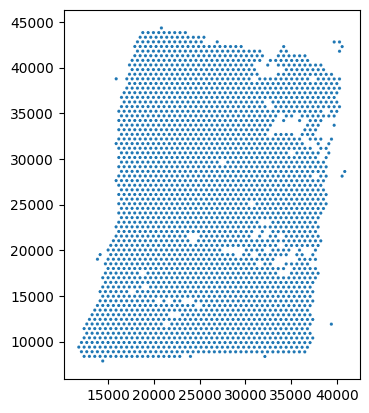

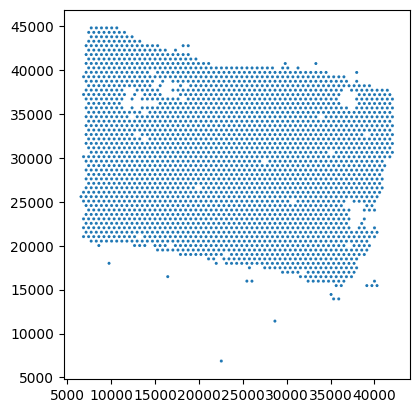

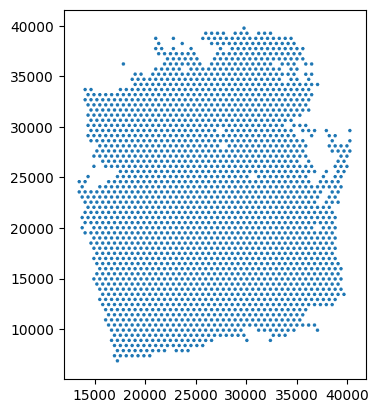

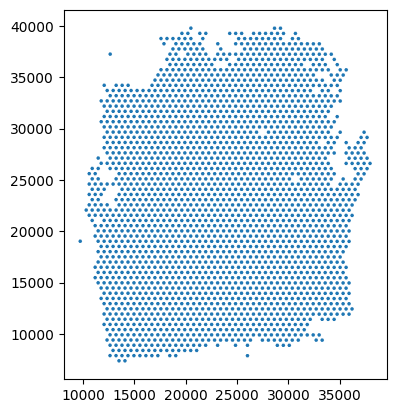

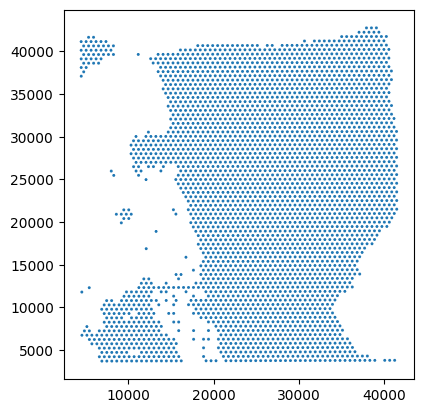

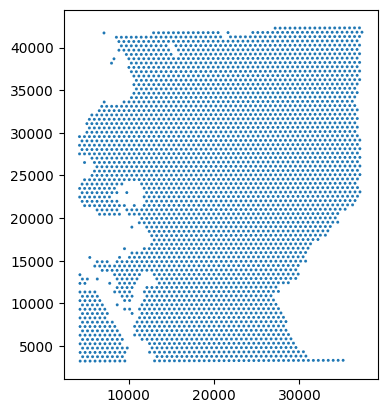

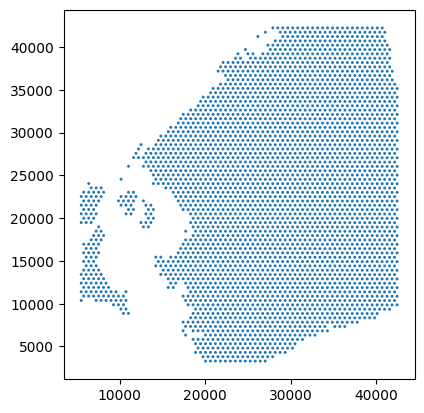

In [4]:
for row in info.iterrows():
    visiumid = row[1]['Visum h5ad ID']
    visium = re.sub('.h5ad', '', visiumid)
    # Load geojson file with tumor and stroma annotation
    path = '/Users/tili/Desktop/CIIR/results/Tissue_annotation_qupath_geojson_output/' + visium + '.geojson'
    gdf = geopandas.read_file(path)

    # Load corresponding visium spot geojson file
    id = row[1]['sampleID']
    path = '/Users/tili/Desktop/CIIR/data/Visium_circle_geojson/' + id + '_circle_data.geojson'
    sp = geopandas.read_file(path)
    sp2 = sp.copy()

    # Create polygon from the geojson point 
    sp = sp.assign(geometry = [create_regular_polygon(x.geometry,x.radius,6) for i,x in sp.iterrows()])

    # Get the tumor and stroma index
    cla = gdf['classification']
    if cla[0].get('name') == "Tumor":
        print(cla[0].get('name'))
        tumor = 0
        stroma = 1
    elif cla[0].get('name') == "Stroma":
        tumor = 1
        stroma = 0

    # Print visium spot and geojson file to see if they match
    gdf.geometry[tumor]
    point = list(sp.geometry)
    # Create a GeoDataFrame
    gdf_visium = geopandas.GeoDataFrame({'geometry': point})
    gdf_visium.plot()

    # Calculate tumor and stroma fraction
    spdf = pd.DataFrame([{'x':x.x, 'y':x.y} for x in sp2.geometry])
    tumor_fraction = sp.geometry.apply(lambda x:x.intersection(gdf.geometry[tumor]).area/x.area)
    stroma_fraction = sp.geometry.apply(lambda x:x.intersection(gdf.geometry[stroma]).area/x.area)

    # Save results to the sp data
    spdf = spdf.assign(tumor_frac = tumor_fraction)
    spdf = spdf.assign(stromal_frac = stroma_fraction)
    spdf = spdf.assign(cellid = sp.cellid)

    # Save the results as csv file
    path = '/Users/tili/Desktop/CIIR/results/Tissue_annotation_qupath_analyzed/' + id + '_tissue.csv'
    spdf.to_csv(path)